Training Loss at Epoch : 1 is  0.2703
Validation Accuracy at Epoch : 1 is  0.9494
Training Loss at Epoch : 2 is  0.1430
Validation Accuracy at Epoch : 2 is  0.9655
Training Loss at Epoch : 3 is  0.1216
Validation Accuracy at Epoch : 3 is  0.9735
Training Loss at Epoch : 4 is  0.0958
Validation Accuracy at Epoch : 4 is  0.9760
Training Loss at Epoch : 5 is  0.0925
Validation Accuracy at Epoch : 5 is  0.9789
Training Loss at Epoch : 6 is  0.0863
Validation Accuracy at Epoch : 6 is  0.9776
Training Loss at Epoch : 7 is  0.0945
Validation Accuracy at Epoch : 7 is  0.9805
Training Loss at Epoch : 8 is  0.0735
Validation Accuracy at Epoch : 8 is  0.9822
Training Loss at Epoch : 9 is  0.0751
Validation Accuracy at Epoch : 9 is  0.9831
Training Loss at Epoch : 10 is  0.0601
Validation Accuracy at Epoch : 10 is  0.9816
Training Loss at Epoch : 11 is  0.0386
Validation Accuracy at Epoch : 11 is  0.9827
Training Loss at Epoch : 12 is  0.0380
Validation Accuracy at Epoch : 12 is  0.9802
Training L

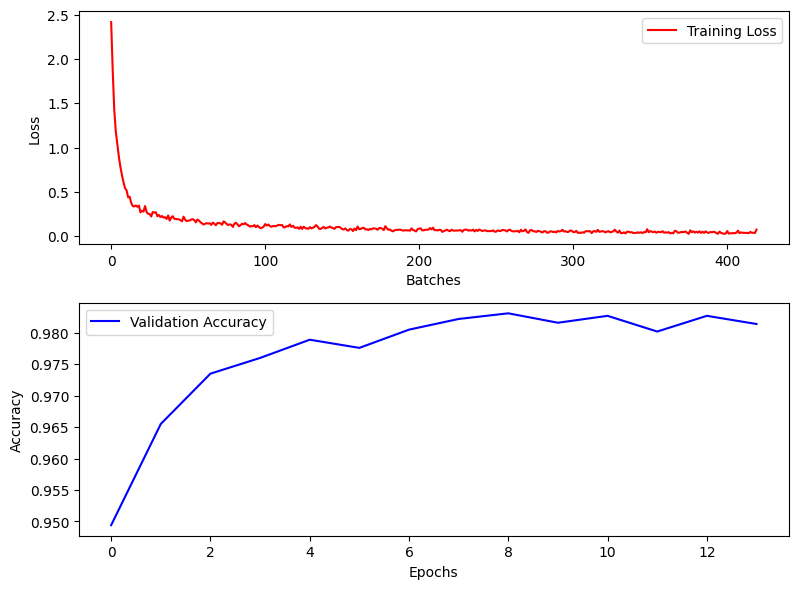

In [22]:
#import modules and libraries

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets as dsets
from torchvision import transforms

#Setup the manual seed for reproducing the test results
torch.manual_seed(2)

#Define the ModuleList subclass

class NeuralNet(nn.Module):

    def __init__(self, Layers, dropout_p=0.3):
        super().__init__()

        self.hidden = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropout = nn.Dropout(p=dropout_p)

        for input_size,output_size in zip(Layers,Layers[1:]):
            self.hidden.append(nn.Linear(input_size,output_size))
            self.batch_norms.append(nn.BatchNorm1d(output_size))

    def forward(self, activation):
        L = len(self.hidden)
        for i,(Linear_transform, Batch_Norm) in enumerate(zip(self.hidden,self.batch_norms)):
            if i < L-1:
                activation =  Linear_transform(activation)
                activation =  Batch_Norm(activation)
                activation =  torch.relu(activation)
                activation =  self.dropout(activation)
            else:

                activation = Linear_transform(activation)

        return activation
    

# Define the dataset and loader

train_dataset = dsets.MNIST(root='./data', train=True,download=True,transform=transforms.ToTensor())
train_loader = DataLoader(dataset=train_dataset,batch_size=2000,shuffle=True)

test_dataset =  dsets.MNIST(root='./data', train=False,download=True,transform=transforms.ToTensor())
test_loader = DataLoader(dataset=test_dataset,batch_size=5000,shuffle=False)

#Setup the model definition


Layers = [784,512,256,128,64,10]
model =  NeuralNet(Layers)

#print( "Model paramters", model.state_dict())

#Setup Loss fn and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)


#Setup the training Loop

metrics_list = { 'training_loss':[], 'validation_accuracy':[] }
epochs = 100
patience = 5
best_accuracy = 0
no_improve_count = 0
dropout_rate = 0.3

def model_training(n_epochs):
    for epoch in range(n_epochs):
        global best_accuracy, no_improve_count

        model.train() #Training Mode enabled
        for x,y in train_loader:
            optimizer.zero_grad()
            z = model(x.view(-1,28*28))
            loss = criterion(z,y)
            loss.backward()
            optimizer.step()
            metrics_list['training_loss'].append(loss.data.item())
        print(f"Training Loss at Epoch : {epoch+1} is {metrics_list['training_loss'][-1]: .4f}")

        model.eval() #Evaluation Mode enabled
        with torch.no_grad():
            accuracy = 0
            correct = 0
            for x_test,y_test in test_loader:
                z = model(x_test.view(-1,28*28))
                _,yhat_test = torch.max(z,1)
                correct += (yhat_test==y_test).sum().item()

            accuracy = correct / len(test_dataset)
            metrics_list['validation_accuracy'].append(accuracy)
        print(f"Validation Accuracy at Epoch : {epoch+1} is {metrics_list['validation_accuracy'][-1]: .4f}")
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

# Perform model training

trained_model = model_training(epochs)

#Plot the loss and accuracy metrics

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(metrics_list['training_loss'], color='r', label='Training Loss')
ax1.set_xlabel("Batches")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(metrics_list['validation_accuracy'], color='b', label='Validation Accuracy')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()
